In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint, choice



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'

DIR_TRAINED = "TRAINED_MODELS"

SAMPLING = '60min'
SAMPLING_MIN = 60
MONTHS_HISTORY = 8

# CREATION GRAPH

In [3]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NODE_TO_IDX = {node: idx for idx, node in enumerate(NODE_LIST)}
IDX_TO_NODE = {idx: node for idx, node in enumerate(NODE_LIST)}

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [4]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,70.89,70.89,187.51,187.51,70.89,67.64,116.62,73.91,52.57,3.25,12.87,2.20,6.27,41.54,1.17,52.57
2024-01-01 01:00:00,83.72,83.72,240.73,240.73,83.72,80.06,157.01,87.35,65.37,3.66,14.69,0.00,7.29,67.88,1.77,65.37
2024-01-01 02:00:00,64.94,64.94,199.59,199.59,64.94,61.29,134.64,67.32,41.79,3.65,19.50,0.00,6.02,65.37,1.96,41.79
2024-01-01 03:00:00,77.43,77.43,197.07,197.07,77.43,74.10,119.64,83.49,63.30,3.33,10.80,0.00,9.39,35.01,1.14,63.30
2024-01-01 04:00:00,71.09,71.09,208.94,208.94,71.09,66.68,137.85,73.87,54.43,4.41,12.25,0.00,7.19,62.38,1.61,54.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,960.44,960.44,2813.98,2813.98,960.44,913.25,1853.54,1057.84,476.36,47.19,153.54,283.36,144.59,779.32,16.38,476.36
2024-06-28 20:00:00,745.39,745.39,2143.38,2143.38,745.39,707.21,1397.99,830.29,380.54,38.18,119.33,207.33,123.08,554.45,13.26,380.54
2024-06-28 21:00:00,835.15,835.15,2381.77,2381.77,835.15,797.71,1546.62,920.58,443.85,37.44,121.43,232.43,122.87,610.78,15.27,443.85
2024-06-28 22:00:00,1255.06,1255.06,3581.79,3581.79,1255.06,1197.25,2326.72,1371.27,657.64,57.81,204.42,335.19,174.02,933.95,21.50,657.64


# GMAN MATRICES

## ADJACENCY MATRIX

In [5]:
def get_line_adjacency_matrix(G, NODE_LIST):
    """
    Returns the adjacency matrix of G_line as a numpy array, 
    preserving the order specified in NODE_LIST.
    """
    return nx.to_numpy_array(G, nodelist=NODE_LIST)

ADJ_MATRIX = get_line_adjacency_matrix(G_router, NODE_LIST)
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=NODE_LIST, index=NODE_LIST).astype(int)
print("Adjacency Matrix:")
ADJ_MATRIX_DF

Adjacency Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MR_A,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
HR_B,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
MR_B,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
A,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
B,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
S7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## INCIDENCE MATRIX

In [6]:
def build_node_conservation_matrix(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels

INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix(G_router, NODE_LIST)
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=NODE_LIST, index=row_labels)
print("Incidence Matrix:")
display(INCIDENCE_MATRIX_DF)

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)
Incidence Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


The average loss is: 0.0004000000000026005


## NODE MASKS

In [7]:
INNER_NODES_MASK =  (INCIDENCE_MATRIX_DF == 1).sum()
LEAF_NODES_MASK = (INNER_NODES_MASK == 0)*1

print(f"INNER_NODES_MASK: {INNER_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.iloc[i]])
print()
print(f"LEAF_NODES_MASK: {LEAF_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.iloc[i]])

INNER_NODES_MASK: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

LEAF_NODES_MASK: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']


## MASK ATTENTION MASK

In [139]:
def generate_node_reconstruction_mask_numpy(G_physical, node_list, k_hops=1):
    """
    Generates a Node-to-Node Spatial Attention Mask as a NumPy array.
    
    Args:
        G_physical (nx.DiGraph): The router-to-router graph.
        node_list (list): The EXACT list of nodes in the desired order. 
        k_hops (int): Depth of vision (how far downstream to look).
        
    Returns:
        np.ndarray: Shape [N, N], dtype=bool.
                    True  = Blocked / Masked (Cannot attend).
                    False = Visible / Allowed (Can attend).
    """
    num_nodes = len(node_list)
    print(f"--- Generating Ordered Node Mask (NumPy) ---")
    
    # 1. Create Mapping
    # Ensures Row 0 is node_list[0], Row 1 is node_list[1]...
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    
    # 2. Initialize Mask
    # Default is True (Blocked/Hidden)
    mask = np.ones((num_nodes, num_nodes), dtype=bool)
    
    # 3. Build Connectivity
    for i, u in enumerate(node_list):
        
        if u not in G_physical:
            print(f"⚠️ Warning: Node '{u}' not found in graph.")
            continue
            
        # A. Self-Attention (Always Allow)
            mask[i, i] = False

        
        # B. Downstream Lookup
        try:
            # Find all nodes 'v' reachable from 'u' within k_hops
            descendants = nx.single_source_shortest_path_length(G_physical, u, cutoff=k_hops)
            
            for v in descendants:
                if v in node_to_idx:
                    j = node_to_idx[v]
                    mask[i, j] = False # Make visible
            
            #if re.match(r'S\d+', u):
            #    mask[i, i] = False
            #else:
            #    mask[i, i] = True 
                    
        except Exception as e:
            print(f"Error processing node {u}: {e}")

   
    # Stats
    total_cells = num_nodes * num_nodes
    visible_cells = (~mask).sum() # Count False values
    print(f"✅ Mask Created. Shape ({num_nodes}, {num_nodes}). Visible Connections: {visible_cells}")
    
    return mask

NODE_LIST_IDX = {x:i for i,x in enumerate(NODE_LIST)}
ATT_MASK = generate_node_reconstruction_mask_numpy(G_router, NODE_LIST, k_hops=1)

for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']:
    ATT_MASK[NODE_LIST_IDX[node_idx], NODE_LIST_IDX[node_idx]] = True

ATT_MASK_DF = pd.DataFrame(ATT_MASK, columns=NODE_LIST, index=NODE_LIST)*1
print("Reconstruction Attention Mask:")

ATT_MASK_T = torch.tensor(ATT_MASK).to(torch.bool)

ATT_MASK_DF



ATT_MASK_DF = pd.DataFrame(np.zeros((16, 16), dtype=bool), columns=NODE_LIST, index=NODE_LIST)
for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S1','S2','S3','S4','S5','S6','S7']:
    ATT_MASK_DF.loc[node_idx,node_idx] = True


display(ATT_MASK_DF)
ATT_MASK_T = torch.tensor(ATT_MASK_DF.values).to(torch.bool)


--- Generating Ordered Node Mask (NumPy) ---
✅ Mask Created. Shape (16, 16). Visible Connections: 32
Reconstruction Attention Mask:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
MR_A,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
HR_B,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
MR_B,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
C,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
D,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
A,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
B,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
E,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
S7,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


# PARAMETERS

In [140]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
#FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
#FREQ_MINUTES = FREQ_H*60

NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
PRED_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 256

STEPS_PER_DAY = int(24*60/SAMPLING_MIN)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 8
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {SAMPLING_MIN} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 24
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 256
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 8
Dimension of each head: 32


# DATASETS / DATALOADERS

In [153]:
class MaskedFlowDataset(Dataset):
    def __init__(self, data_scaled, seq_len, inner_mask):
        """
        Args:
            data_scaled (np.ndarray or torch.Tensor): The fully scaled dataset. 
                                                      Shape: (Total_Timesteps, Num_Nodes)
            seq_len (int): The length of the time window (lookback = prediction length).
            inner_mask (torch.Tensor or list): 1 for inner nodes (to be masked out), 
                                               0 for measured leaf nodes. Shape: (Num_Nodes,)
        """
        # Convert data to tensor if it isn't already
        self.data = torch.tensor(data_scaled, dtype=torch.float32)
        self.seq_len = seq_len
        
        # Ensure mask is a boolean tensor for easy indexing
        # True means "this is an inner node, hide it"
        self.inner_mask = torch.tensor(inner_mask, dtype=torch.bool)
        
        # We can generate (Total_Timesteps - seq_len + 1) valid windows
        self.num_samples = len(self.data) - self.seq_len + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Grab the true time window (Target Y)
        # Shape: (seq_len, Num_Nodes)
        window_y = self.data[idx : idx + self.seq_len]
        
        # 2. Create the Input X by copying Y
        window_x = window_y.clone()
        
        # 3. Mask out the inner nodes in X
        # We set them to 0 (which, for StandardScaler data, is exactly the mean)
        # This tells the model: "I have no information about these nodes."
        
        window_x[:,self.inner_mask] = 0.0
        
        return window_x, window_y

In [154]:
from sklearn.preprocessing import StandardScaler

INNER_MASK = (1 - LEAF_NODES_MASK.values)

SCALER = StandardScaler()
DATA_RAW_MODEL_SCALED = SCALER.fit_transform(DATA_RAW_MODEL.values)

total_samples = len(DATA_RAW_MODEL_SCALED)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size


train_data = DATA_RAW_MODEL_SCALED[:train_size].copy()
val_data = DATA_RAW_MODEL_SCALED[train_size:].copy()

TSS_TRAIN_DS = MaskedFlowDataset(
    data_scaled=train_data,
    seq_len=HIST_STEPS,
    inner_mask=INNER_MASK
)

TSS_VAL_DS = MaskedFlowDataset(
    data_scaled=val_data,
    seq_len=HIST_STEPS,
    inner_mask=INNER_MASK
)

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")



TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")


if DEBUG:
    from random import randint

    _rand_idx = randint(0,len(TSS_TRAIN_DS))
    print()
    print(f"Random index: {_rand_idx}")
    X_real = DATA_RAW_MODEL.values[_rand_idx]
    print()
    print("X real:")
    print(X_real)

    _sample = TSS_TRAIN_DS[_rand_idx]

    X_scaled = _sample[0]
    Y_scaled = _sample[1]

    print()
    print('Data Scaled Masked')
    print(X_scaled[0])
    print()
    print(f"Scaler mean: {SCALER.mean_}")
    print(f"Scaler scale: {SCALER.scale_}")


    X_un = (X_scaled * SCALER.scale_) + SCALER.mean_
    print()
    print("Data unscaled")
    print(X_un[0])

Total valid sliding windows: 4320
Train size: 3433
Val size: 841
Train samples: 108 | Val samples: 27

Random index: 2250

X real:
[ 767.42  767.42 2271.05 2271.05  767.42  727.57 1503.62  850.65  382.43
   39.85  123.09  222.06  123.07  636.81   16.17  382.43]

Data Scaled Masked
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        1.1290, 1.3613, 0.8640, 1.4046, 1.0780, 1.3459, 1.0614])

Scaler mean: [ 373.12406019  373.12406019 1088.65234259 1088.65234259  373.12406019
  354.26484259  715.52817361  404.37190278  184.42775694   18.85921528
   50.93228472  118.90484259   50.10715509  304.61181713    6.544125
  184.42775694]
Scaler scale: [ 371.18690516  371.18690516 1080.81467473 1080.81467473  371.18690516
  353.02157867  711.18338988  402.18186502  186.54361488   18.59197646
   53.00709653  119.39174172   51.9454336   308.17125072    7.15223885
  186.54361488]

Data unscaled
tensor([ 373.1241,  373.1241, 1088.6523, 1088.6523,  373.1241,  354.2648,


# MODEL
## ITransformer

In [155]:
class iTransformer(nn.Module):
    """
    iTransformer: Inverted Transformer for Time Series Forecasting.
    
    Ref: iTransformer: Inverted Transformers are Effective for Time Series Forecasting
    """
    def __init__(self, num_variates, hist_steps, pred_steps, d_model=512, n_heads=8, num_layers=2, dropout=0.1, attn_mask=None):
        super(iTransformer, self).__init__()
        
        self.hist_steps = hist_steps
        self.pred_steps = pred_steps
        self.d_model = d_model

        # 1. Embedding: Project the entire lookback window (T) to feature dimension (D)
        # In iTransformer, the MLP acts on the time dimension.
        # Input: (Batch, Num_Variates, Lookback_Len) -> Output: (Batch, Num_Variates, d_model)
        self.embedding = nn.Linear(hist_steps, d_model)
        
        # 2. Transformer Encoder: Captures multivariate correlations
        # The sequence length here is 'Num_Variates', not time steps.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            dropout=dropout, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Projection: Project feature dimension (D) to prediction horizon (S)
        # Input: (Batch, Num_Variates, d_model) -> Output: (Batch, Num_Variates, Pred_Len)
        self.projection = nn.Linear(d_model, pred_steps)

        if attn_mask is not None:
            # We force it to float() right here to prevent TypeErrors later
            print(f"✔️ Att mask set")
            self.register_buffer('attn_mask', attn_mask.float())
        else:
            self.attn_mask = None

    def forward(self, x):
        # x shape: [Batch, hist_steps, Num_Variates]
        
        # Step 1: Invert dimensions to [Batch, Num_Variates, hist_steps]
        # This treats each variate as a "token" and the time series as the "embedding"
        x = x.permute(0, 2, 1) 
        
        # Step 2: Embedding (Linear Layer applied to the time dimension)
        # x shape becomes: [Batch, Num_Variates, d_model]
        x = self.embedding(x)
        
        # Step 3: Multivariate Interaction (Self-Attention)
        # Attention is calculated between variates.
        x = self.encoder(x, mask=self.attn_mask)
        
        # Step 4: Projection to forecast horizon
        # x shape becomes: [Batch, Num_Variates, pred_steps]
        x = self.projection(x)
        
        # Step 5: Invert back to [Batch, pred_steps, Num_Variates] to match ground truth
        x = x.permute(0, 2, 1)
        
        return x

if DEBUG:
    embedding = nn.Linear(HIST_STEPS, D_MODEL)

    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=D_MODEL * 4, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )

    encoder = nn.TransformerEncoder(encoder_layer, num_layers=LAYERS_ENC_DEC)

    projection = nn.Linear(D_MODEL, PRED_STEPS)
 
    for X_d, Y_d in TSS_TRAIN_DL:
            if randint(0,10) == 4:
                break

    print(f"X_d shape: {X_d.shape}")
    print(f"Y_d shape: {Y_d.shape}")

    X_d = X_d.permute(0, 2, 1)
    print(f"X_d shape inverted: {X_d.shape}")

    X_d = embedding(X_d)
    print(f"X_d shape embedded: {X_d.shape}")

    X_d = encoder(X_d)
    print(f"X_d shape encoded: {X_d.shape}")

    X_d = projection(X_d)
    print(f"X_d shape projected: {X_d.shape}")

    X_d = X_d.permute(0, 2, 1)
    print(f"X_d shape inverted: {X_d.shape}")

X_d shape: torch.Size([32, 24, 16])
Y_d shape: torch.Size([32, 24, 16])
X_d shape inverted: torch.Size([32, 16, 24])
X_d shape embedded: torch.Size([32, 16, 256])
X_d shape encoded: torch.Size([32, 16, 256])
X_d shape projected: torch.Size([32, 16, 24])
X_d shape inverted: torch.Size([32, 24, 16])


# TRAINNIG

In [156]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


# SIMULATION

### LOSS FUNCTION

In [145]:
LEAF_NODES_MASK.values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

ADJ_MATRIX_T.shape: torch.Size([16, 16])
INCIDENCE_MATRIX_T.shape: torch.Size([9, 16])
SHape MEAN: torch.Size([1, 1, 16])
SHape STD: torch.Size([1, 1, 16])
Shape X_scaled_masked: torch.Size([32, 24, 16])
Shape X_scaled_real: torch.Size([32, 24, 16])
Shape X_masked: torch.Size([32, 24, 16])
Shape X_real: torch.Size([32, 24, 16])

################ BottomUpReconstructionLoss ########################
Shape rand_flow: torch.Size([32, 24, 16])
Loss: 8.397662895731628e-06
################### CombinedTrafficLoss #####################
Total Loss: 37875712000.0
Data Loss: 450833.75
Physics Loss: 378752598016.0


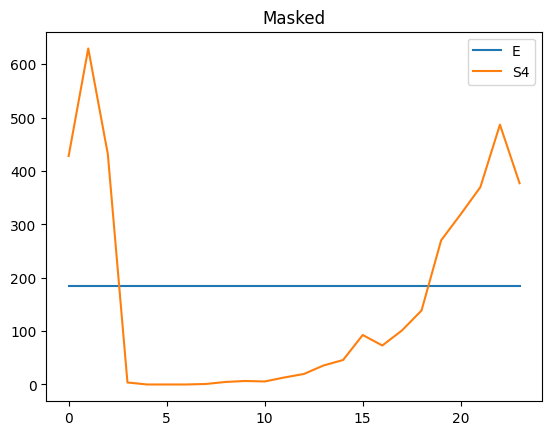

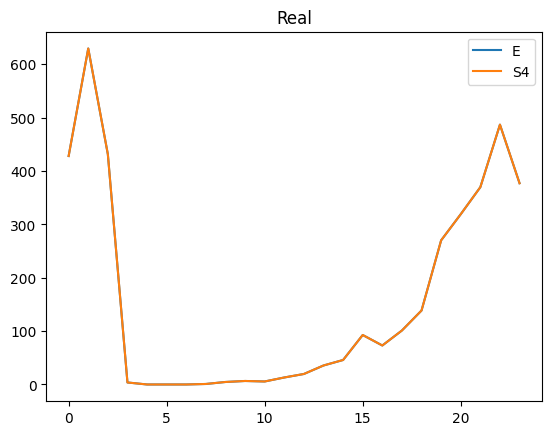

In [146]:
class BottomUpReconstructionLoss(nn.Module):
    def __init__(self, G_physical, device='cpu'):
        super(BottomUpReconstructionLoss, self).__init__()
        
        # Adjacency: Rows=Parents, Cols=Children
        adj = nx.to_numpy_array(G_physical)
        self.adj_matrix = torch.tensor(adj, dtype=torch.float32).to(device)
      
        
        # Identify Parents (Nodes with outgoing edges/children)
        row_sum = self.adj_matrix.sum(dim=1)
        self.parent_mask = (row_sum > 0).float().view(1, 1, -1).to(device)

    def forward(self, Y_pred_real, Y_true_real):
        # 1. Mix flows: Use Ground Truth for Leaves (Mask=1), Preds for Parents (Mask=0)
        # This propagates the "True" leaf traffic up to the parents
        
        #F_children = Y_pred_real
        # 2. Reshape for Matrix Mult: [Batch*Time, Nodes]


        #B, T, C = F_children.shape
        #F_flat = F_children.reshape(B*T,C)
        
        # 3. Sum Children to find Expected Parent Flow
        # Parent_i = Sum(A_ij * Child_j) -> MatMul(F, A.T)
        #F_reconstructed_flat = torch.matmul(F_flat, self.adj_matrix.t())
        #F_reconstructed_flat = torch.matmul(self.adj_matrix, F_flat.T)
        #F_reference = F_reconstructed_flat.reshape(B, T, C)

        y_reconstructed= Y_pred_real @ self.adj_matrix.T
        y_parent_true = Y_true_real*self.parent_mask
        
        # 4. Compare: Does Model's Parent Prediction == Sum of Children?
        # Note: We compare against Y_pred_real (what the model thinks the parent is)
        #diff = Y_pred_real - F_reference
        #diff = Y_true_real - F_reference
        diff = y_parent_true - y_reconstructed

        
        # 5. Mask: Only punish Parent nodes (leaves don't have children to sum)
        #loss = diff.sum(dim=-1)**2
        loss = (diff ** 2) #* self.parent_mask
        
        return loss.mean()

class CombinedTrafficLoss(nn.Module):
    def __init__(self, G_physical, scaler_mean, scaler_std, inner_mask, device='cpu', lambda_phy=0.1, lambda_mse=1):
        """
        Args:
            G_physical: NetworkX graph (Parent -> Child edges).
            scaler_mean: The mean used to scale the data.
            scaler_std: The standard deviation used to scale the data.
            device: 'cuda' or 'cpu'.
            lambda_phy: Weighting factor for the physics loss (default 0.1).
        """
        super(CombinedTrafficLoss, self).__init__()
        self.lambda_phy = lambda_phy
        self.lambda_mse = lambda_mse
        self.device = device
        
        # 1. Standard Data Loss (MSE)
        self.mse = nn.MSELoss()
        
        # 2. Physics Loss (Bottom-Up Reconstruction)
        self.bottom_up = BottomUpReconstructionLoss(G_physical, device)
        
        # 3. Stats for Differentiable Reverse Transform
        # We need these to convert Z-scores to Real Flow inside the loss
       
        self.means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
        self.scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)
        self.inner_mask =  torch.as_tensor(inner_mask, device=device).bool()



    def forward(self, Y_pred, Y_true):
        """
        Args:
            Y_pred: Model output (Normalized Z-Scores)
            Y_true: Ground Truth (Normalized Z-Scores)
        """
        B,T,C = Y_true.shape



        ## CHANGE!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        Y_pred[:,:,~self.inner_mask] = Y_true[:,:,~self.inner_mask]

        # --- 1. Data Loss (MSE) ---
        # Calculated on Normalized data (Standard Deep Learning practice)
        
        loss_data = self.mse(Y_pred, Y_true)
        
        # --- 2. Physics Preparation (Reverse Transform) ---
        # We must un-scale the data to check Flow Conservation.
        # Since this is just (X * std) + mean, it preserves Gradients!
        Y_pred_real = (Y_pred * self.scale) + self.means
        Y_true_real = (Y_true * self.scale) + self.means
   
        # --- 3. Physics Loss (Bottom-Up) ---
        # Calculated on Real Units
        loss_physics = self.bottom_up(Y_pred_real, Y_true_real)
        
        # --- 4. Combine ---
        total_loss = (self.lambda_mse * loss_data) + (self.lambda_phy * loss_physics)


        return total_loss, loss_data, loss_physics
        
if DEBUG:
    SCALER_MEAN_T = torch.tensor(SCALER.mean_).view(1,1,-1).float()
    SCALER_STD_T = torch.tensor(SCALER.scale_).view(1,1,-1).float()
    INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX)
    ADJ_MATRIX_T = torch.tensor(ADJ_MATRIX)
    print(f"ADJ_MATRIX_T.shape: {ADJ_MATRIX_T.shape}")
    print(f"INCIDENCE_MATRIX_T.shape: {INCIDENCE_MATRIX_T.shape}")
    print(f"SHape MEAN: {SCALER_MEAN_T.shape}")
    print(f"SHape STD: {SCALER_STD_T.shape}")

    parent_mask = (ADJ_MATRIX_T.sum(dim=1) > 0).float().view(1, 1, -1)

    from random import randint
    for batch_idx, (X_scaled_masked, X_scaled_real) in enumerate(TSS_TRAIN_DL):
        if randint(0,10) == 3:
            break

    print(f"Shape X_scaled_masked: {X_scaled_masked.shape}")
    print(f"Shape X_scaled_real: {X_scaled_real.shape}")
    

    X_masked = ((X_scaled_masked * SCALER_STD_T) + SCALER_MEAN_T).float()
    X_real = ((X_scaled_real * SCALER_STD_T) + SCALER_MEAN_T).float()
    print(f"Shape X_masked: {X_masked.shape}")
    print(f"Shape X_real: {X_real.shape}")
    

    ax = pd.DataFrame(X_masked[0,:,:].numpy(), columns=NODE_LIST)[['E','S4']].plot(title='Masked')
    pd.DataFrame(X_real[0,:,:].numpy(), columns=NODE_LIST)[['E','S4']].plot( title='Real')

    rand_flow = X_real
    rand_flow_masked = X_scaled_real
    print()
    print("################ BottomUpReconstructionLoss ########################" )
    phy_loss = BottomUpReconstructionLoss(G_router, 'cpu')

    
    print(f"Shape rand_flow: {rand_flow.shape}")
    loss = phy_loss(rand_flow, rand_flow)
    print(f"Loss: {loss}")

    print("################### CombinedTrafficLoss #####################")
    combined_loss = CombinedTrafficLoss(G_router,SCALER_MEAN_T, SCALER_STD_T, INNER_MASK, 'cpu')
    total_loss, loss_data, loss_physics = combined_loss(rand_flow_masked, rand_flow)
    print(f"Total Loss: {total_loss}")
    print(f"Data Loss: {loss_data}")
    print(f"Physics Loss: {loss_physics}")
    

['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

In [160]:

import torch.nn.functional as F

print(NODE_LIST[0:9])

class PartialMSELoss(nn.Module):
    def __init__(self, feature_indices):
        super(PartialMSELoss, self).__init__()
        # Store indices of the features you care about
        self.feature_indices = feature_indices

    def forward(self, y_pred, y_true):
        # Slice both tensors to keep only the features at feature_indices
        # Assuming shape is [batch, features] or [batch, nodes, features]
        y_pred_sliced = y_pred[..., self.feature_indices]
        y_true_sliced = y_true[..., self.feature_indices]
        
        # Calculate MSE only on these features
        return F.mse_loss(y_pred_sliced, y_true_sliced)



['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']


In [161]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=None #ATT_MASK_T
).to(DEVICE)


SCALER_MEAN_T = torch.tensor(SCALER.mean_).clone().to(DEVICE)
SCALER_STD_T = torch.tensor(SCALER.scale_).clone().to(DEVICE) 

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

optimizer = torch.optim.Adam(MODEL.parameters(), lr=0.01) #LR)

#loss_fn = CombinedTrafficLoss(
#        G_physical=G_router, 
#        scaler_mean=SCALER_MEAN_T, 
#        scaler_std=SCALER_STD_T, 
#        inner_mask=INNER_MASK,
#        device=DEVICE, 
#        lambda_phy=10,
#        lambda_mse=1
#).to(DEVICE)

#loss_fn = nn.MSELoss().to(DEVICE)

loss_fn = PartialMSELoss(feature_indices=[0,9])


Checkpoint path: TRAINED_MODELS/best_model_itransformer_att_phy_mask_node_sim.pth


### TRAINING

In [162]:
PATIENCE = 5

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

CHECKPOINT_PATH = f'{DIR_TRAINED}/best_early_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)

Checkpoint path: TRAINED_MODELS/best_early_model_itransformer_att_phy_mask_node_sim.pth


In [163]:
print("Starting Training...")


EPOCHS = 30*3
epoch_task_loss_arr = []
epoch_kcl_loss_arr = []

for epoch in range(EPOCHS):
    MODEL.train()
    
    # Trackers for the different loss components
    epoch_total_loss = 0.0
    epoch_task_loss = 0.0
    epoch_kcl_loss = 0.0

    
    for batch_idx, (x_batch, y_batch) in enumerate(TSS_TRAIN_DL):
        # Move data to GPU/CPU
        X_scaled_masked = x_batch.to(DEVICE)
        X_scaled = y_batch.to(DEVICE)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward Pass: Predict the full window (both leaves and inner nodes)
        # x_batch has inner nodes masked to 0.0
        y_pred = MODEL(X_scaled_masked)
        
        # Calculate Loss
        # total_loss drives the optimizer. The others are for our monitoring.
        #total_loss, task_loss, kcl_penalty = loss_fn(y_pred, X_scaled)
        total_loss = loss_fn(y_pred, X_scaled)

        # Backward Pass & Optimize
        total_loss.backward()
        
        # Optional: Gradient clipping is often helpful for transformers
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update trackers
        epoch_total_loss += total_loss.item()
        #epoch_task_loss += task_loss.item()
        #epoch_kcl_loss += kcl_penalty.item()


    # Early Stopping
    early_stopping(epoch_total_loss, MODEL)
    if early_stopping.early_stop:
        print("Early stopping triggered. Training stopped.")
        break

    # Load best model
    MODEL.load_state_dict(torch.load(CHECKPOINT_PATH))
    print("Best model weights loaded for testing.")


    #epoch_task_loss_arr.append(epoch_task_loss/len(TSS_TRAIN_DL))
    #epoch_kcl_loss_arr.append(epoch_kcl_loss/len(TSS_TRAIN_DL))
        
    # Calculate averages for the epoch
    num_batches = len(TSS_TRAIN_DL)
    avg_total = epoch_total_loss / num_batches
    #avg_task = epoch_task_loss / num_batches
    #avg_kcl = epoch_kcl_loss / num_batches
    avg_task = 0
    avg_kcl = 0
    
    # Print progress
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Total: {avg_total:.4f} | "
          f"Task (Leaves MSE): {avg_task:.4f} | "
          f"Physics (KCL Violation): {avg_kcl:.4f}")


OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Validation loss decreased (inf --> 85.353057).  Saving model ...
Best model weights loaded for testing.
Epoch [1/90] Total: 0.7903 | Task (Leaves MSE): 0.0000 | Physics (KCL Violation): 0.0000
Validation loss decreased (85.353057 --> 37.881013).  Saving model ...
Best model weights loaded for testing.
Epoch [2/90] Total: 0.3508 | Task (Leaves MSE): 0.0000 | Physics (KCL Violation): 0.0000
Validation loss decreased (37.881013 --> 26.820829).  Saving model ...
Best model weights loaded for testing.
Epoch [3/90] Total: 0.2483 | Task (Leaves MSE): 0.0000 | Physics (KCL Violation): 0.0000
Validation loss decreased (26.820829 --> 22.620701).  Saving model ...
Best model weights loaded for testing.
Epoch [4/90] Total: 0.2095 | Task (Leaves MSE): 0.0000 | Physics (KCL Violation): 0.0000
EarlyStopping counter: 1 out of 5
Best model weights loaded for testing.
Epoch [5/90] Total: 0.2210 | Task (Leaves MSE): 0.0000 | Physics (KCL Violation): 0.0000
Validation loss decreased (

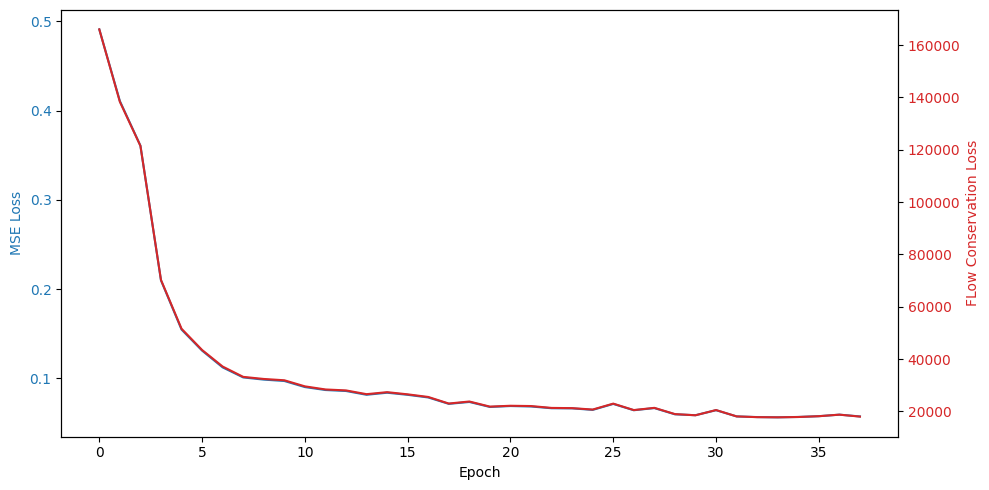

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss', color='tab:blue')
ax1.plot(epoch_task_loss_arr, color='tab:blue', label='MSE Loss')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('FLow Conservation Loss', color='tab:red')
ax2.plot(epoch_kcl_loss_arr, color='tab:red', label='FLow Conservation Loss')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.show()



### RECONSTRUCTION OF FLOWS

In [164]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask= None #ATT_MASK_T
)

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_trained.pth


<All keys matched successfully>

### VALIDATION

In [126]:

def validate_model(model, dataloader, criterion, scale, means, device,  channel=None):
    """
    Validates the model and calculates Scaled Loss, Real MAE, and Real RMSE.
    """

    if channel is not None:
        print(f"Channel: {channel}")
    
    model.eval()
    
    total_scaled_loss = 0.0
    total_real_mae = 0.0
    total_real_mse = 0.0  
    
    # Ensure scale and means are Tensors and on the correct device
    if not isinstance(scale, torch.Tensor):
        scale = torch.tensor(scale, dtype=torch.float32)
    if not isinstance(means, torch.Tensor):
        means = torch.tensor(means, dtype=torch.float32)
        
    scale = scale.to(device)
    means = means.to(device)

    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (X, Y_true_scaled) in enumerate(dataloader):
            
            X = X.to(device)
            Y_true_scaled = Y_true_scaled.to(device)
            
            # Forward Pass
            Y_pred_scaled = model(X)
            
            # Calculate Scaled Loss (MSE for backprop monitoring)
            loss = criterion(Y_pred_scaled, Y_true_scaled)
            total_scaled_loss += loss.item()
            
            # INVERSE TRANSFORM (Z-Scores -> Real Units)
            Y_pred_real = (Y_pred_scaled * scale) + means
            Y_true_real = (Y_true_scaled * scale) + means

            
            if channel is not None:
                Y_pred_real = Y_pred_real[:, :, channel]
                Y_true_real = Y_true_real[:, :, channel]
            
            mae = torch.mean(torch.abs(Y_pred_real - Y_true_real))
            total_real_mae += mae.item()
            
            mse_real = torch.mean((Y_pred_real - Y_true_real) ** 2)
            total_real_mse += mse_real.item()
            
    # Calculate averages over all batches
    avg_scaled_loss = total_scaled_loss / len(dataloader)
    avg_real_mae = total_real_mae / len(dataloader)
    avg_real_mse = total_real_mse / len(dataloader)
    
    # RMSE is the square root of the overall average MSE <-- ADDED
    avg_real_rmse = avg_real_mse ** 0.5
    
    return avg_scaled_loss, avg_real_mae, avg_real_rmse

def validate_plots(model, dataloader, scaler_mean, scaler_std, device, num_nodes_to_plot=3):
    import random
    """
    Takes a random batch from the dataloader, predicts, and plots the results.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader (Shuffle=True recommended for randomness).
        device: 'cuda' or 'cpu'.
        node_mode: Optional mask for heterogeneous nodes.
        num_nodes_to_plot: How many random nodes to visualize from the sample.
    """

    model.eval()
    means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
    scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)


    
    # 1. Get a single batch
    # We use next(iter()) which grabs the first batch. 
    # If your loader has shuffle=True, this is random.
  
    X, Y_true_scaled = next(iter(dataloader))


    # Move to Device
    X = X.to(device)
    B,T,C = X.shape
    
    # 2. Inference
    with torch.no_grad():
        Y_pred_scaled = model(X)

    # 3. Inverse Transform (Get Real Units)
    # The dataset handles the math to get back to Gbps/Mbps

    Y_true_real = (Y_true_scaled * scale) + means
    Y_pred_real = (Y_pred_scaled * scale) + means
        

    # 4. Select a Random Sample from the Batch
    batch_size = Y_true_real.shape[0]
    sample_idx = random.randint(0, batch_size - 1)
    
    # 5. Select Random Nodes to Plot
    num_nodes = Y_true_real.shape[2]
    # Ensure we don't try to plot more nodes than exist
    nodes_to_plot = random.sample(range(num_nodes), min(num_nodes, num_nodes_to_plot))
    
    # 6. Plotting
    fig, axes = plt.subplots(len(nodes_to_plot), 1, figsize=(10, 4 * len(nodes_to_plot)), sharex=True)
    if len(nodes_to_plot) == 1: axes = [axes] # Handle single plot case
    
    time_steps = np.arange(Y_true_real.shape[1]) # 0 to Q-1
    
    print(f"📊 Visualization for Batch Sample #{sample_idx}")
    
    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        
        # Extract data for this specific node and sample
        truth = Y_true_real[sample_idx, :, node_idx]
        pred = Y_pred_real[sample_idx, :, node_idx]
        
        # Plot
        ax.plot(time_steps, truth, label='Ground Truth', color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(time_steps, pred, label='Reconstruction', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        # Formatting
        ax.set_title(f"Node Index: {node_idx}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Traffic (Real Units)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend()

    plt.xlabel("Prediction Time Steps (Future)")
    plt.tight_layout()
    plt.show()



Channel: 0
Channel: 1
Channel: 2
Channel: 3
Channel: 4
Channel: 5
Channel: 6
Channel: 7
Channel: 8
Channel: 9
Channel: 10
Channel: 11
Channel: 12
Channel: 13
Channel: 14
Channel: 15
📊 Visualization for Batch Sample #1


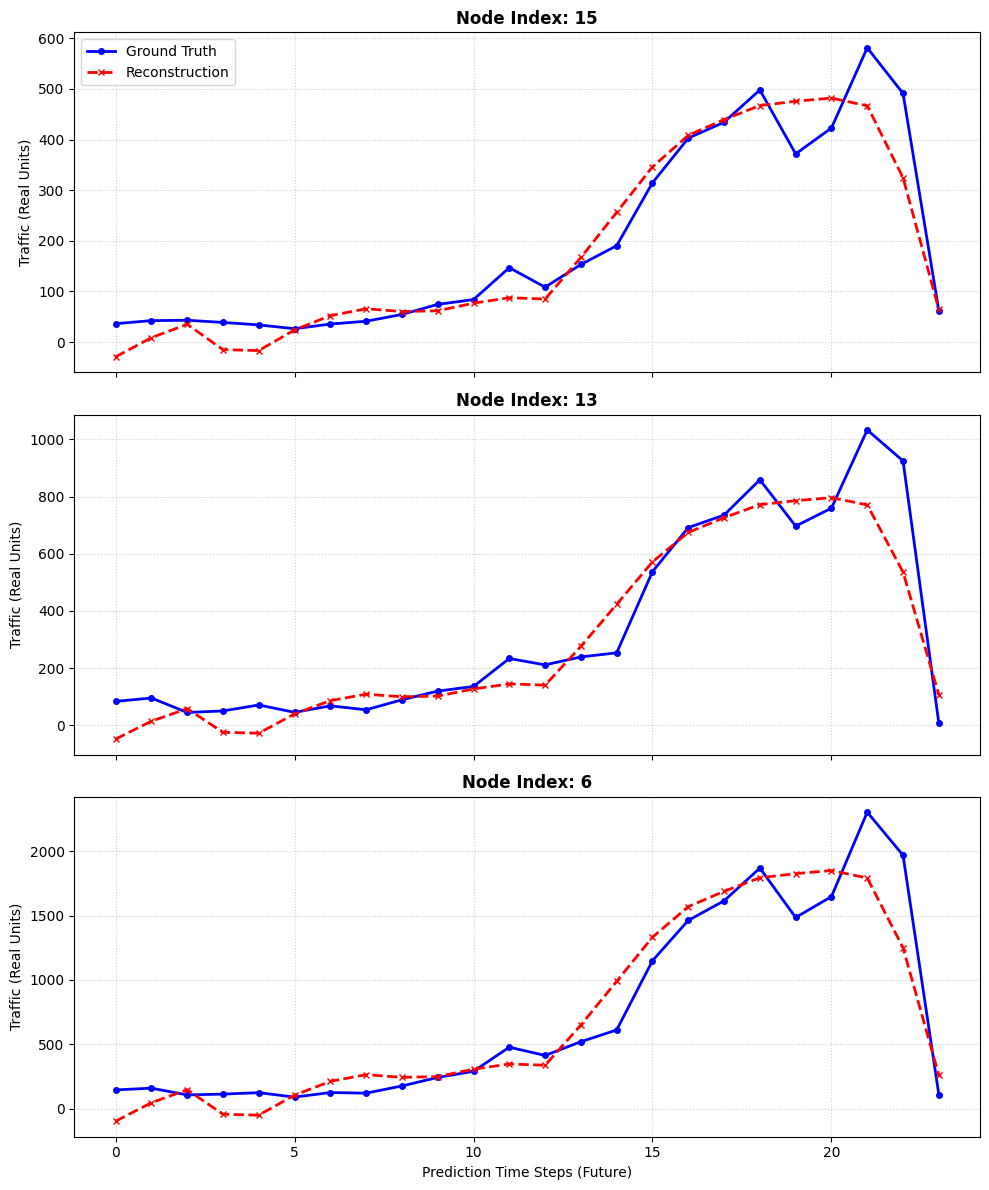

Validation Loss: 0.12927533437808356
Validation MAE: 79.12183283094657
Validation RMSE: 155.56623633738283


In [33]:

criterion = torch.nn.MSELoss()

ERR_TABLE_NODE = []
for i,node in enumerate(NODE_LIST):
    val_loss, val_mae, val_rmse = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=i)
    ERR_TABLE_NODE.append([val_loss, val_mae, val_rmse])

ERR_TABLE_NODE = pd.DataFrame(ERR_TABLE_NODE, columns=['Loss', 'MAE', 'RMSE'], index=NODE_LIST).T.round(1)


validate_plots(MODEL, TSS_VAL_DL, SCALER_MEAN_T, SCALER_STD_T, 'cpu', num_nodes_to_plot=3)

#axs = []
#for i in range(LAYERS_ENC_DEC):
#    axs.append(analyze_itransformer_attention(MODEL, TSS_VAL_DL, NODE_LIST, layer_index=i, device='cpu')[1])

val_loss_total, val_mae_total, val_rmse_total = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=None)
print(f"Validation Loss: {val_loss_total}")
print(f"Validation MAE: {val_mae_total}")
print(f"Validation RMSE: {val_rmse_total}")

In [34]:


_output_excel = f'XLS_MODELS/{PREFIX_MODEL}_{SAMPLING}_table.csv'
print(f"Output Excel: {_output_excel}")
ERR_TABLE_NODE.to_csv(_output_excel, sep=';')

Output Excel: XLS_MODELS/model_itransformer_att_phy_mask_node_sim_60min_table.csv


## SCENARIOS: WHAT IF PREDICTION


In [165]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask= None #ATT_MASK_T
)

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)



Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_trained.pth


<All keys matched successfully>

### SCENARIO: NO MODIFICATION

Shape: torch.Size([1, 24, 16])


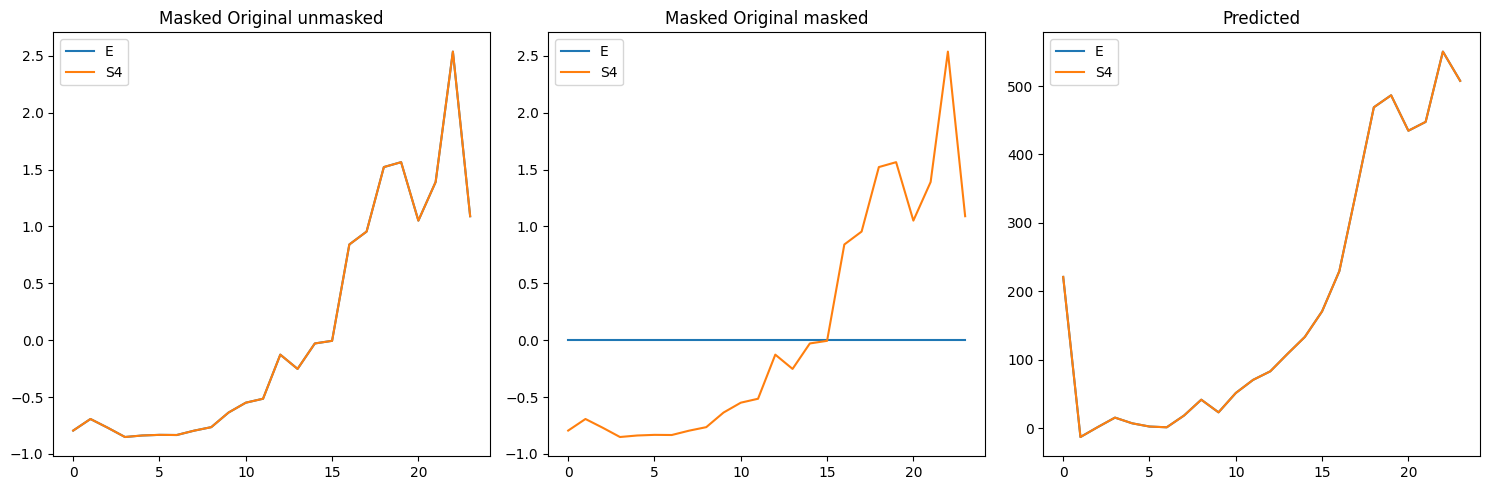

In [166]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS:,:]



SIM_DATA = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(SIM_DATA, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)

SCALER_MEAN_T = torch.tensor(SCALER.mean_).clone().view(1,1,-1)
SCALER_STD_T = torch.tensor(SCALER.scale_).clone().view(1,1,-1) 


X_masked, X_unmasked = next(iter((SIM_DL)))
print(f"Shape: {X_masked.shape}")


MODEL.eval()
with torch.no_grad():
    Y_pred_scaled = MODEL(X_masked)
Y_pred = (Y_pred_scaled*SCALER_STD_T) + SCALER_MEAN_T


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pd.DataFrame(X_unmasked[0].numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[0], title='Masked Original unmasked')
pd.DataFrame(X_masked[0].numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[1], title='Masked Original masked')
pd.DataFrame(Y_pred[0].detach().numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[2], title='Predicted')
plt.tight_layout()
plt.show()


### SCENARIO: DROP 50%

In [167]:
def reconstruct_physical_flow_mask(model, dataloader, scaler_means, scaler_stds, inner_mask, device='cpu'):
    """
    Reconstructs the timeline by merging ground truth leaf nodes with predicted inner nodes.
    
    Args:
        model (nn.Module): The trained iTransformer.
        dataloader (DataLoader): DataLoader using the MaskedFlowDataset.
        scaler_means (torch.Tensor): Means from StandardScaler. Shape: (num_nodes,)
        scaler_stds (torch.Tensor): Stds from StandardScaler. Shape: (num_nodes,)
        inner_mask (list or np.ndarray): 1 (or True) for inner nodes, 0 for leaf nodes.
        device (str): 'cpu' or 'cuda'.
        
    Returns:
        np.ndarray: The merged physical flows. Shape: (Total_Timesteps, Num_Nodes)
        np.ndarray: The original true flows (for reference). Shape: (Total_Timesteps, Num_Nodes)
    """
    model.eval()
    model.to(device)
    
    means = scaler_means.float().to(device).view(1, 1, -1)
    stds = scaler_stds.float().to(device).view(1, 1, -1)
    
    # Ensure the mask is a boolean numpy array for easy indexing later
    mask_np = np.array(inner_mask, dtype=bool)
    
    continuous_preds = []
    continuous_trues = []
    
    with torch.no_grad():
        for x_scaled_maked, y_true_scaled in dataloader:
            x_scaled_maked = x_scaled_maked.to(device)
            y_true_scaled = y_true_scaled.to(device)
            
            # 1. Forward pass
            y_pred_scaled = model(x_scaled_maked)
            
            # 2. Unscale back to physical flow units
            y_pred_unscaled = (y_pred_scaled * stds) + means
            y_true_unscaled = (y_true_scaled * stds) + means
            
            # Move to CPU and convert to NumPy
            preds_np = y_pred_unscaled.cpu().numpy()
            trues_np = y_true_unscaled.cpu().numpy()
            
            # 3. Extract the "Present" (The last timestep of the window)  [1,16]
            step_preds = preds_np[:, -1, :] 
            step_trues = trues_np[:, -1, :]

            #mantener los valores de las hojas
            #step_preds[:, ~mask_np] = step_trues[:, ~mask_np]

           
            
            continuous_preds.append(step_preds)
            continuous_trues.append(step_trues)
            
    # Concatenate all batches vertically
    final_preds = np.concatenate(continuous_preds, axis=0)
    final_trues = np.concatenate(continuous_trues, axis=0)
    
    # ---------------------------------------------------------
    # 4. MERGE TRUES AND PREDICTIONS
    # ---------------------------------------------------------
    # Start with a copy of the perfect ground truth data
    merged_flows = final_trues.copy()
    
    # Overwrite ONLY the inner nodes with the model's predictions
    # mask_np is True for inner nodes, False for leaf nodes
    merged_flows[:, mask_np] = final_preds[:, mask_np]
    
    return merged_flows, final_trues

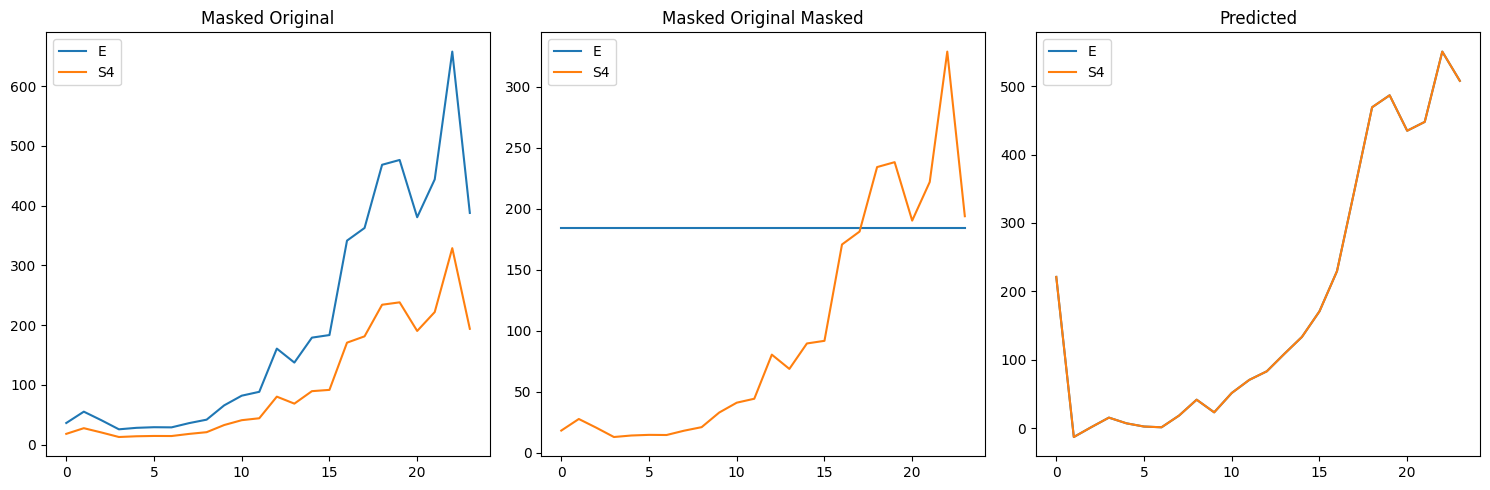

In [168]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS:,:]
DATA_RAW_SIMULATION['S4'] *= 0.5
#DATA_RAW_SIMULATION['E'] = DATA_RAW_SIMULATION['E'].mean()

SIM_DATA = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(SIM_DATA, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)

SCALER_MEAN_T = torch.tensor(SCALER.mean_).clone().view(1,1,-1)
SCALER_STD_T = torch.tensor(SCALER.scale_).clone().view(1,1,-1) 


X_masked, X_unmasked = next(iter((SIM_DL)))

MODEL.eval()
with torch.no_grad():
    Y_pred_scaled = MODEL(X_masked)



X_masked = (X_masked*SCALER_STD_T) + SCALER_MEAN_T
X_unmasked = (X_unmasked*SCALER_STD_T) + SCALER_MEAN_T
Y_pred = (Y_pred_scaled*SCALER_STD_T) + SCALER_MEAN_T


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pd.DataFrame(X_unmasked[0].numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[0], title='Masked Original')
pd.DataFrame(X_masked[0].numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[1], title='Masked Original Masked')
pd.DataFrame(Y_pred[0].detach().numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[2], title='Predicted')
plt.tight_layout()
plt.show()






array([False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True])

HIST 0
HIST 1
HIST 2
HIST 3
HIST 4
HIST 5
HIST 6
HIST 7
HIST 8
HIST 9
HIST 10
HIST 11
HIST 12
HIST 13
HIST 14
HIST 15
HIST 16
HIST 17
HIST 18
HIST 19
HIST 20
HIST 21
HIST 22
HIST 23
HIST 24
HIST 25
HIST 26
HIST 27
HIST 28
HIST 29
HIST 30
HIST 31
HIST 32
HIST 33
HIST 34
HIST 35
HIST 36
HIST 37
HIST 38
HIST 39
HIST 40
HIST 41
HIST 42
HIST 43
HIST 44
HIST 45
HIST 46
HIST 47
HIST 48
HIST 49
HIST 50
HIST 51
HIST 52
HIST 53
HIST 54
HIST 55
HIST 56
HIST 57
HIST 58
HIST 59
HIST 60
HIST 61
HIST 62
HIST 63
HIST 64
HIST 65
HIST 66
HIST 67
HIST 68
HIST 69
HIST 70
HIST 71
HIST 72
HIST 73
HIST 74
HIST 75
HIST 76
HIST 77
HIST 78
HIST 79
HIST 80
HIST 81
HIST 82
HIST 83
HIST 84
HIST 85
HIST 86
HIST 87
HIST 88
HIST 89
HIST 90
HIST 91
HIST 92
HIST 93
HIST 94
HIST 95
HIST 96
HIST 97
HIST 98
HIST 99
HIST 100
HIST 101
HIST 102
HIST 103
HIST 104
HIST 105
HIST 106
HIST 107
HIST 108
HIST 109
HIST 110
HIST 111
HIST 112
HIST 113
HIST 114
HIST 115
HIST 116
HIST 117
HIST 118
HIST 119
HIST 120
HIST 121
HIST 122
HIS

<Axes: >

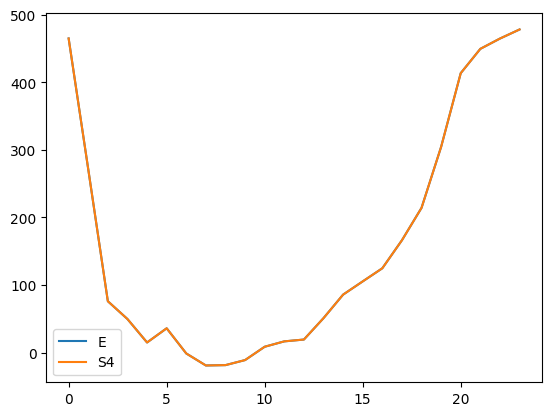

In [ ]:
data_simulation = DATA_RAW_SIMULATION.copy()
data_simulation = data_simulation.iloc[-HIST_STEPS:,:]
data_simulation['S4'] *= 0.5


data_simulation_scaled = SCALER.transform(data_simulation.values)

LEAF_MASK = (1-INNER_MASK).astype(bool)

for i in range((HIST_STEPS)):
    print(f"HIST {i}")

    _sim_ds = MaskedFlowDataset(data_simulation_scaled, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
    _X_masked_scaled, _X_true_scaled = _sim_ds[0]

    #display(f"_X_masked_scaled.shape: {_X_masked_scaled.shape}")
    #display(f"_X_true_scaled.shape: {_X_true_scaled.shape}")

    with torch.no_grad():
        _pred_scaled = MODEL(_X_masked_scaled.unsqueeze(0))

    _pred_scaled_last = _pred_scaled[0][-1].unsqueeze(0).numpy()

    #_pred_unscaled = (_pred_scaled*SCALER_STD_T) + SCALER_MEAN_T


    #display(f"_pred_scaled_last.shape: {_pred_scaled_last.shape}")
    #display(f"data_simulation_scaled.shape: {data_simulation_scaled.shape}")

    #_pred_df = pd.DataFrame([_pred_scaled_last], columns=NODE_LIST, index=[DATA_RAW_SIMULATION.index[i]])
    #display(_pred_df)

    #display(data_simulation_scaled.shape)

    data_simulation_scaled = np.concatenate([data_simulation_scaled, _pred_scaled_last], axis=0)
    data_simulation_scaled = data_simulation_scaled[-HIST_STEPS:,:]
    #data_simulation_scaled[:,LEAF_MASK] = _X_true_scaled[:,LEAF_MASK]
    

    #display(data_simulation_scaled.shape)
    
    
pd.DataFrame(SCALER.inverse_transform(data_simulation_scaled), columns=NODE_LIST)[['E','S4']].plot()
  

<Axes: >

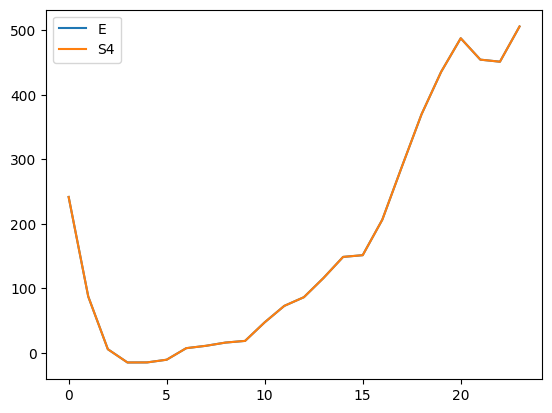

<Axes: >

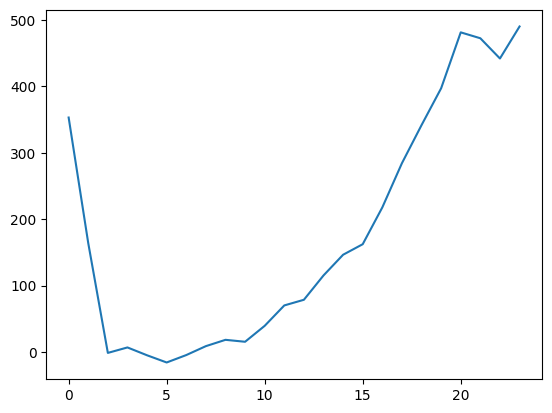

In [ ]:
  predicted_flows, true_flows = reconstruct_physical_flow_mask(
        model=MODEL,
        dataloader=_sim_dl,
        scaler_means=SCALER_MEAN_T,
        scaler_stds=SCALER_STD_T,
        inner_mask=INNER_MASK,
        device='cpu'
    )

    data_simulation = pd.concat([
        data_simulation,
        pd.DataFrame(predicted_flows, columns=NODE_LIST, index= [DATA_RAW_SIMULATION.index[i]])
        ])
    data_simulation = data_simulation.iloc[-HIST_STEPS:,:]

    _sim_data = SCALER.transform(data_simulation.values)
    _sim_ds = MaskedFlowDataset(_sim_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
    _sim_dl = DataLoader(_sim_ds, batch_size=BATCH_SIZE, shuffle=False)

<Axes: >

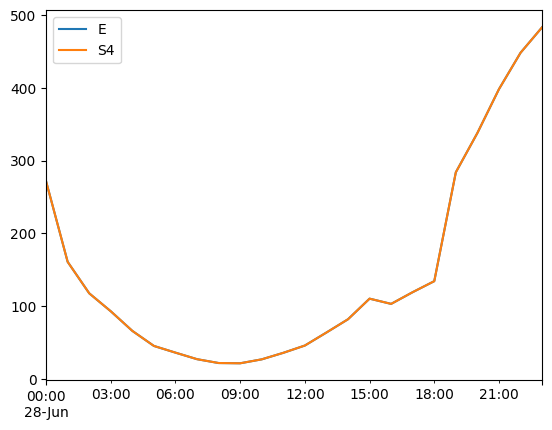

In [ ]:
data_simulation[['E','S4']].plot()

## SCENARIOS: WHAT IFS

In [ ]:
def reconstruct_physical_flow(model, dataloader, scaler_means, scaler_stds, device='cpu'):
    """
    Runs inference to reconstruct masked inner nodes (state estimation).
    Extracts the final timestep of each sliding window to build a continuous timeline.
    
    Args:
        model (nn.Module): The trained iTransformer.
        dataloader (DataLoader): DataLoader using the MaskedFlowDataset.
        scaler_means (torch.Tensor): Means from StandardScaler. Shape: (num_nodes,)
        scaler_stds (torch.Tensor): Stds from StandardScaler. Shape: (num_nodes,)
        device (str): 'cpu' or 'cuda'.
        
    Returns:
        np.ndarray: Continuous reconstructed predictions. Shape: (Total_Timesteps, Num_Nodes)
        np.ndarray: Continuous true values. Shape: (Total_Timesteps, Num_Nodes)
    """
    model.eval()
    model.to(device)
    
    # Reshape scalers for broadcasting: (1, 1, Num_Nodes)
    means = scaler_means.float().to(device).view(1, 1, -1)
    stds = scaler_stds.float().to(device).view(1, 1, -1)
    
    continuous_preds = []
    continuous_trues = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x_scaled_maked = x.to(device)
            x_scaled = y.to(device)
            
            # 1. Forward pass: Reconstruct the current masked window
            x_pred_scaled = model(x_scaled_maked)
            
            # 2. Unscale back to physical flow units
            x_pred_unscaled = (x_pred_scaled * stds) + means    
            x_unscaled = (x_scaled * stds) + means
            
            # Move to CPU and convert to NumPy
            preds_np = x_pred_unscaled.cpu().numpy()
            trues_np = x_unscaled.cpu().numpy()
            
            # 3. Extract the "Present" (The last timestep of the window)
            # Shape goes from (Batch, Seq_Len, Nodes) -> (Batch, Nodes)
            step_preds = preds_np[:, -1, :]
            step_trues = trues_np[:, -1, :]
            
            continuous_preds.append(step_preds)
            continuous_trues.append(step_trues)
            
    # 4. Concatenate all batches vertically into a single continuous 2D array
    final_preds = np.concatenate(continuous_preds, axis=0)
    final_trues = np.concatenate(continuous_trues, axis=0)
    
    return final_preds, final_trues

def reconstruct_physical_flow_mask(model, dataloader, scaler_means, scaler_stds, inner_mask, device='cpu'):
    """
    Reconstructs the timeline by merging ground truth leaf nodes with predicted inner nodes.
    
    Args:
        model (nn.Module): The trained iTransformer.
        dataloader (DataLoader): DataLoader using the MaskedFlowDataset.
        scaler_means (torch.Tensor): Means from StandardScaler. Shape: (num_nodes,)
        scaler_stds (torch.Tensor): Stds from StandardScaler. Shape: (num_nodes,)
        inner_mask (list or np.ndarray): 1 (or True) for inner nodes, 0 for leaf nodes.
        device (str): 'cpu' or 'cuda'.
        
    Returns:
        np.ndarray: The merged physical flows. Shape: (Total_Timesteps, Num_Nodes)
        np.ndarray: The original true flows (for reference). Shape: (Total_Timesteps, Num_Nodes)
    """
    model.eval()
    model.to(device)
    
    means = scaler_means.float().to(device).view(1, 1, -1)
    stds = scaler_stds.float().to(device).view(1, 1, -1)
    
    # Ensure the mask is a boolean numpy array for easy indexing later
    mask_np = np.array(inner_mask, dtype=bool)
    
    continuous_preds = []
    continuous_trues = []
    
    with torch.no_grad():
        for x_scaled_maked, y_true_scaled in dataloader:
            x_scaled_maked = x_scaled_maked.to(device)
            y_true_scaled = y_true_scaled.to(device)
            
            # 1. Forward pass
            y_pred_scaled = model(x_scaled_maked)
            
            # 2. Unscale back to physical flow units
            y_pred_unscaled = (y_pred_scaled * stds) + means
            y_true_unscaled = (y_true_scaled * stds) + means
            
            # Move to CPU and convert to NumPy
            preds_np = y_pred_unscaled.cpu().numpy()
            trues_np = y_true_unscaled.cpu().numpy()
            
            # 3. Extract the "Present" (The last timestep of the window)  [1,16]
            step_preds = preds_np[:, -1, :] 
            step_trues = trues_np[:, -1, :]

            #mantener los valores de las hojas
            step_preds[:, ~mask_np] = step_trues[:, ~mask_np]

           
            
            continuous_preds.append(step_preds)
            continuous_trues.append(step_trues)
            
    # Concatenate all batches vertically
    final_preds = np.concatenate(continuous_preds, axis=0)
    final_trues = np.concatenate(continuous_trues, axis=0)
    
    # ---------------------------------------------------------
    # 4. MERGE TRUES AND PREDICTIONS
    # ---------------------------------------------------------
    # Start with a copy of the perfect ground truth data
    #merged_flows = final_trues.copy()
    
    # Overwrite ONLY the inner nodes with the model's predictions
    # mask_np is True for inner nodes, False for leaf nodes
    #merged_flows[:, mask_np] = final_preds[:, mask_np]
    
    return final_preds, final_trues

def validate_kcl_compliance(predicted_flows, adjacency_matrix, inner_mask):
    """
    Checks how well the reconstructed flows obey Flow In = Flow Out at the inner nodes.
    
    Args:
        predicted_flows (np.ndarray): The unscaled model outputs. Shape: (Timesteps, Nodes)
        adjacency_matrix (np.ndarray or list): The A matrix. Shape: (Nodes, Nodes)
        inner_mask (np.ndarray or list): Boolean mask for inner nodes. Shape: (Nodes,)
    """
    # 1. Ensure everything is a NumPy array
    Y = np.array(predicted_flows)
    A = np.array(adjacency_matrix)
    mask = np.array(inner_mask, dtype=bool)
    
    # 2. Calculate Flow In and Flow Out for the entire network
    # Matrix multiplication: (Timesteps, Nodes) @ (Nodes, Nodes) -> (Timesteps, Nodes)
    flow_in = Y @ A 
    flow_out = Y
    
    # 3. Calculate the absolute violation (Error) at every timestep
    # We only care about the inner nodes, so we slice using the mask
    inner_flow_in = flow_in[:, mask]
    inner_flow_out = flow_out[:, mask]
    
    violations = np.abs(inner_flow_in - inner_flow_out)
    
    # 4. Report the metrics
    mean_violation = np.mean(violations)
    max_violation = np.max(violations)
    
    print("--- Physics Validation Report ---")
    print(f"Number of Inner Nodes Checked: {sum(mask)}")
    print(f"Total Timesteps Checked: {Y.shape[0]}")
    print(f"Average KCL Violation (Error): {mean_violation:.4f} units of flow")
    print(f"Maximum Single-Step Violation: {max_violation:.4f} units of flow")
    
    return violations

def plot_inner_node_physics(predicted_flows, adjacency_matrix, node_idx, node_name=None, time_range=None):
    """
    Plots the reconstructed flow of a specific inner node alongside its KCL violation.
    
    Args:
        predicted_flows (np.ndarray): The continuous unscaled predictions. Shape: (Timesteps, Nodes)
        adjacency_matrix (np.ndarray): The A matrix mapping flow direction. Shape: (Nodes, Nodes)
        node_idx (int): The index of the inner node you want to visualize.
        time_range (tuple): Optional (start, end) indices to zoom in on a specific time window.
        node_name:  Name of the node analysed
    """
    Y = np.array(predicted_flows)
    A = np.array(adjacency_matrix)
    
    # 1. Calculate Flow In and Flow Out for this specific node
    # Flow In = The sum of flows from all upstream nodes pointing to node_idx
    # We get this by multiplying the full flow matrix by the specific column for node_idx in A
    flow_in = Y @ A[:, node_idx] 
    
    # Flow Out = The model's prediction for this node itself
    flow_out = Y[:, node_idx]
    
    # KCL Violation (Absolute Error)
    kcl_error = np.abs(flow_in - flow_out)
    
    # 2. Handle zooming in on a specific time window
    if time_range is not None:
        start, end = time_range
        flow_in = flow_in[start:end]
        flow_out = flow_out[start:end]
        kcl_error = kcl_error[start:end]
        time_steps = np.arange(start, end)
    else:
        time_steps = np.arange(len(Y))
        
    # 3. Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Top Subplot: Flow In vs Flow Out
    ax1.plot(time_steps, flow_in, label="Flow IN (Sum of upstream nodes)", 
             color='#1f77b4', linewidth=2, alpha=0.8)
    ax1.plot(time_steps, flow_out, label=f"Flow OUT (Reconstructed Node {node_idx})", 
             color='#ff7f0e', linewidth=2, linestyle='--')
    
    ax1.set_title(f"Physics Validation: Inner Node {node_name}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Physical Flow Volume", fontsize=12)
    ax1.legend(loc="upper right", fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Bottom Subplot: KCL Error
    ax2.plot(time_steps, kcl_error, label="KCL Violation (|In - Out|)", 
             color='#d62728', linewidth=1.5)
    ax2.fill_between(time_steps, 0, kcl_error, color='#d62728', alpha=0.2)
    
    ax2.set_xlabel("Timestep", fontsize=12)
    ax2.set_ylabel("Absolute Error", fontsize=12)
    ax2.legend(loc="upper right", fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


## NO MODIFICATION

Recon size: 97


<Axes: title={'center': 'Reconstruction of E and S4'}>

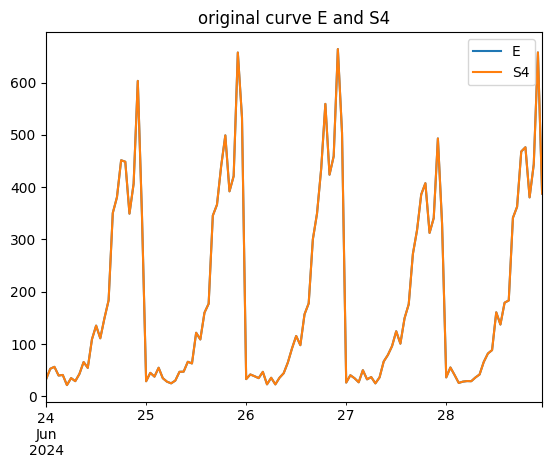

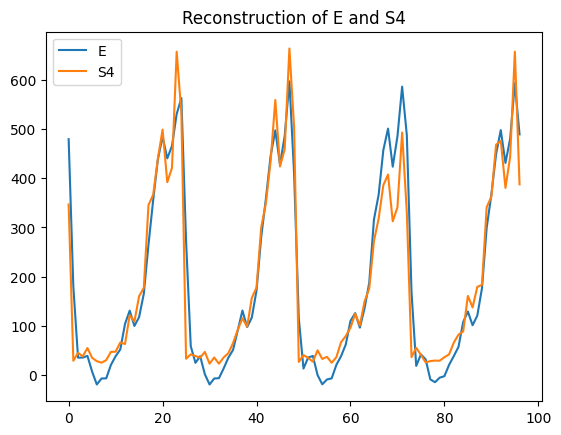

In [ ]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*5:,:]


recon_data = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(recon_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)
print(f"Recon size: {len(SIM_DS)}")

DATA_RAW_SIMULATION[['E','S4']].plot(title='original curve E and S4')
#DATA_RAW_SIMULATION[['C','S7','D']].plot(title='original curve C, S7 and D')


predicted_flows, true_flows = reconstruct_physical_flow_mask(
    model=MODEL,
    dataloader=SIM_DL,
    scaler_means=SCALER_MEAN_T,
    scaler_stds=SCALER_STD_T,
    inner_mask=INNER_MASK,
    device='cpu'
)

#violation_history = validate_kcl_compliance(
#    predicted_flows, 
#    ADJ_MATRIX, 
#    INNER_MASK
#)

#plot_inner_node_physics(
#    predicted_flows=predicted_flows, 
#    adjacency_matrix=ADJ_MATRIX, 
#    node_idx=NODE_TO_IDX['S4'], 
#    node_name='S4',
#    time_range=(0, 50) 
#)

pd.DataFrame(predicted_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4')
#pd.DataFrame(predicted_flows, columns=NODE_LIST)[['C','S7','D']].plot(title='Reconstruction of C, S7 and D')
#validate_model(MODEL, RECON_DL, SCALER, 'cpu')
#validate_plots(MODEL, RECON_DL, SCALER, 'cpu', num_nodes_to_plot=3)

#val_loss_total, val_mae_total, val_rmse_total = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=None)
#print(f"Validation Loss: {val_loss_total}")
#print(f"Validation MAE: {val_mae_total}")
#print(f"Validation RMSE: {val_rmse_total}")

## WHATF IF S4 increase to 1.5

Recon size: 97


<Axes: title={'center': 'Reconstruction of E and S4'}>

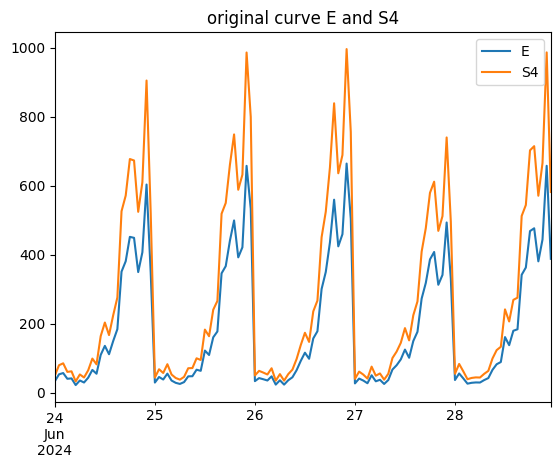

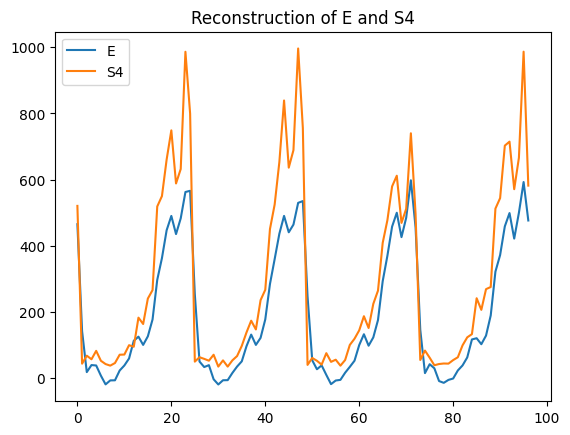

In [ ]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*5:,:]
DATA_RAW_SIMULATION['S4'] *= 1.5


recon_data = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(recon_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)
print(f"Recon size: {len(SIM_DS)}")

DATA_RAW_SIMULATION[['E','S4']].plot(title='original curve E and S4')
#DATA_RAW_SIMULATION[['C','S7','D']].plot(title='original curve C, S7 and D')


predicted_flows, true_flows = reconstruct_physical_flow_mask(
    model=MODEL,
    dataloader=SIM_DL,
    scaler_means=SCALER_MEAN_T,
    scaler_stds=SCALER_STD_T,
    inner_mask=INNER_MASK,
    device='cpu'
)

#violation_history = validate_kcl_compliance(
#    predicted_flows, 
#    ADJ_MATRIX, 
#    INNER_MASK
#)

#plot_inner_node_physics(
#    predicted_flows=predicted_flows, 
#    adjacency_matrix=ADJ_MATRIX, 
#    node_idx=NODE_TO_IDX['S4'], 
#    node_name='S4',
#    time_range=(0, 50) 
#)

pd.DataFrame(predicted_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4')
#pd.DataFrame(true_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4 true')

#pd.DataFrame(predicted_flows, columns=NODE_LIST)[['C','S7','D']].plot(title='Reconstruction of C, S7 and D')
#validate_model(MODEL, RECON_DL, SCALER, 'cpu')
#validate_plots(MODEL, RECON_DL, SCALER, 'cpu', num_nodes_to_plot=3)

#val_loss_total, val_mae_total, val_rmse_total = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=None)
#print(f"Validation Loss: {val_loss_total}")
#print(f"Validation MAE: {val_mae_total}")
#print(f"Validation RMSE: {val_rmse_total}")

## WHAT IF S4 down in 0.5

Recon size: 97


<Axes: title={'center': 'Reconstruction of E and S4'}>

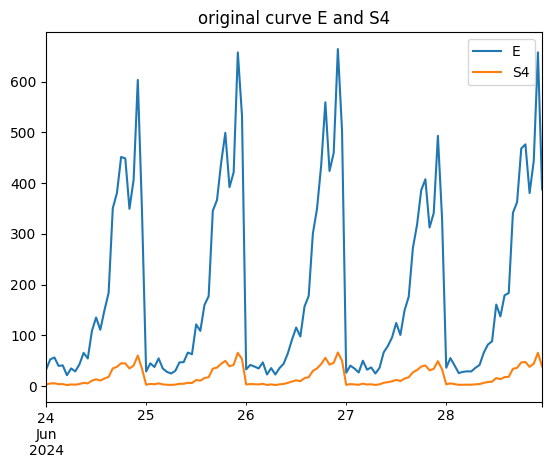

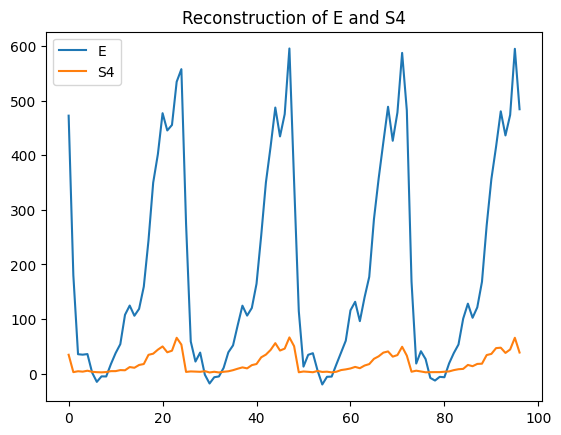

In [ ]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*5:,:]
DATA_RAW_SIMULATION['S4'] *= 0.1


recon_data = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(recon_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)
print(f"Recon size: {len(SIM_DS)}")

DATA_RAW_SIMULATION[['E','S4']].plot(title='original curve E and S4')
#DATA_RAW_SIMULATION[['C','S7','D']].plot(title='original curve C, S7 and D')


predicted_flows, true_flows = reconstruct_physical_flow_mask(
    model=MODEL,
    dataloader=SIM_DL,
    scaler_means=SCALER_MEAN_T,
    scaler_stds=SCALER_STD_T,
    inner_mask=INNER_MASK,
    device='cpu'
)

#violation_history = validate_kcl_compliance(
#    predicted_flows, 
#   ADJ_MATRIX, 
#    INNER_MASK
#)

#plot_inner_node_physics(
#    predicted_flows=predicted_flows, 
#    adjacency_matrix=ADJ_MATRIX, 
#    node_idx=NODE_TO_IDX['S4'], 
#    node_name='S4',
#    time_range=(0, 50) 
#)

pd.DataFrame(predicted_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4')
#pd.DataFrame(predicted_flows, columns=NODE_LIST)[['C','S7','D']].plot(title='Reconstruction of C, S7 and D')
#validate_model(MODEL, RECON_DL, SCALER, 'cpu')
#validate_plots(MODEL, RECON_DL, SCALER, 'cpu', num_nodes_to_plot=3)